# Step 1: Data Preprocessing

This notebook handles the preprocessing of the brain tumor classification dataset including:
- Data loading and exploration
- Visualizing sample images
- Creating train/validation split
- Setting up data augmentation
- Preparing data loaders for training

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1.1 Define Paths and Load Dataset

In [2]:
# Define paths
BASE_DIR = '.'
TRAIN_DIR = os.path.join(BASE_DIR, 'Training')
TEST_DIR = os.path.join(BASE_DIR, 'Testing')

# Class names
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Image properties
IMG_SIZE = (224, 224)  # Common size for models like ResNet, EfficientNet

print(f"Classes: {CLASSES}")
print(f"Training directory: {TRAIN_DIR}")
print(f"Testing directory: {TEST_DIR}")

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Training directory: .\Training
Testing directory: .\Testing


In [3]:
def load_image_paths(directory, classes):
    """Load image paths and labels from directory."""
    image_paths = []
    labels = []
    
    for class_name in classes:
        class_dir = os.path.join(directory, class_name)
        if os.path.exists(class_dir):
            for img_file in os.listdir(class_dir):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    image_paths.append(os.path.join(class_dir, img_file))
                    labels.append(class_name)
    
    return image_paths, labels

# Load training data
train_paths, train_labels = load_image_paths(TRAIN_DIR, CLASSES)
print(f"Training samples: {len(train_paths)}")

# Load test data
test_paths, test_labels = load_image_paths(TEST_DIR, CLASSES)
print(f"Testing samples: {len(test_paths)}")

Training samples: 5600
Testing samples: 1600


## 1.2 Analyze Dataset Distribution

In [4]:
# Count samples per class
train_counts = Counter(train_labels)
test_counts = Counter(test_labels)

# Create DataFrame for visualization
df_counts = pd.DataFrame({
    'Class': CLASSES,
    'Training': [train_counts.get(c, 0) for c in CLASSES],
    'Testing': [test_counts.get(c, 0) for c in CLASSES]
})

print("Dataset Distribution:")
print(df_counts)
print(f"\nTotal Training: {sum(train_counts.values())}")
print(f"Total Testing: {sum(test_counts.values())}")

Dataset Distribution:
        Class  Training  Testing
0      glioma      1400      400
1  meningioma      1400      400
2     notumor      1400      400
3   pituitary      1400      400

Total Training: 5600
Total Testing: 1600


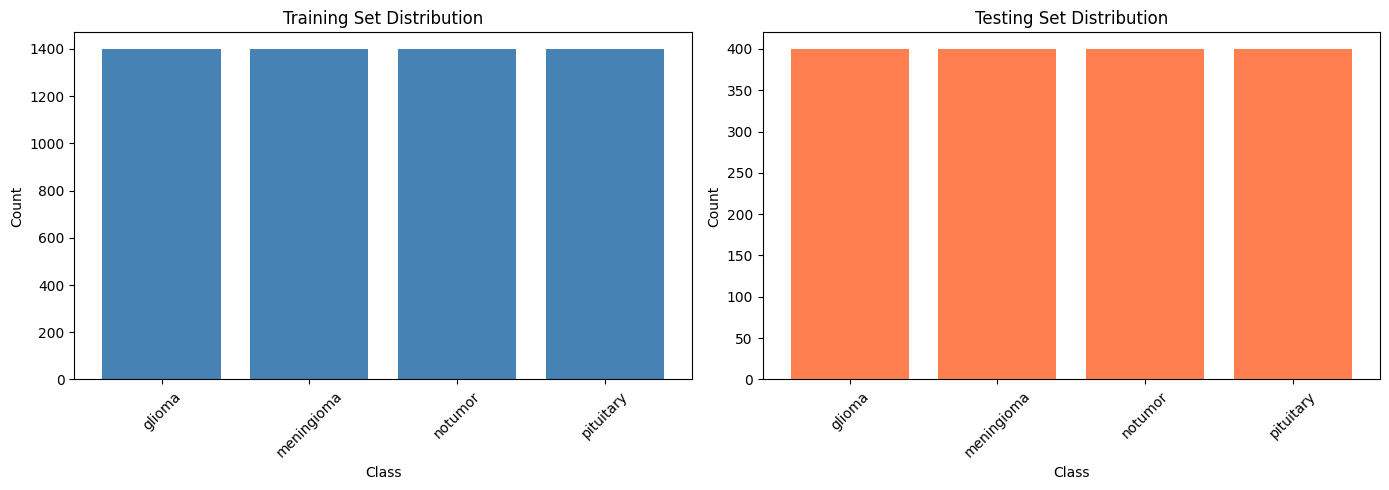

In [5]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training distribution
axes[0].bar(CLASSES, df_counts['Training'], color='steelblue')
axes[0].set_title('Training Set Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Testing distribution
axes[1].bar(CLASSES, df_counts['Testing'], color='coral')
axes[1].set_title('Testing Set Distribution')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 1.3 Visualize Sample Images

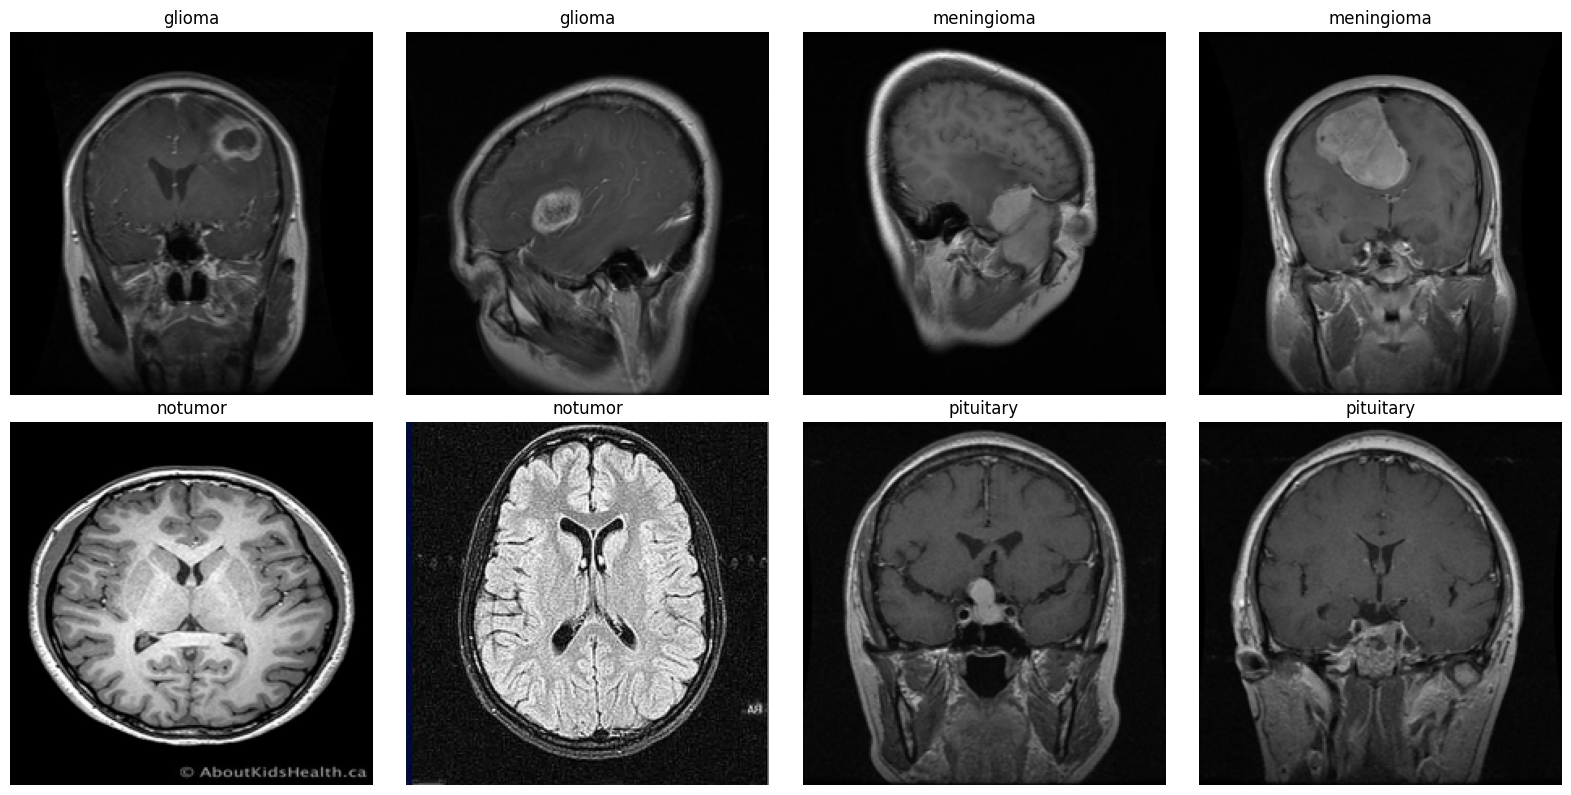

In [6]:
def load_and_preprocess_image(path, target_size=IMG_SIZE):
    """Load and preprocess an image."""
    img = Image.open(path)
    img = img.convert('RGB')  # Ensure 3 channels
    img = img.resize(target_size)
    return np.array(img)

# Display sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, class_name in enumerate(CLASSES):
    # Get sample paths for this class
    class_samples = [p for p, l in zip(train_paths, train_labels) if l == class_name]
    
    # Display two samples per class
    for i in range(2):
        sample_idx = np.random.randint(0, len(class_samples))
        img_array = load_and_preprocess_image(class_samples[sample_idx])
        
        ax = axes[idx * 2 + i]
        ax.imshow(img_array)
        ax.set_title(f"{class_name}")
        ax.axis('off')

plt.tight_layout()
plt.show()

## 1.4 Analyze Image Properties

In [7]:
# Analyze image dimensions and channels
sample_images = []
for class_name in CLASSES:
    class_samples = [p for p, l in zip(train_paths, train_labels) if l == class_name]
    img = load_and_preprocess_image(class_samples[0])
    sample_images.append(img)
    print(f"{class_name}: shape={img.shape}, dtype={img.dtype}, min={img.min():.2f}, max={img.max():.2f}")

glioma: shape=(224, 224, 3), dtype=uint8, min=0.00, max=243.00
meningioma: shape=(224, 224, 3), dtype=uint8, min=0.00, max=244.00
notumor: shape=(224, 224, 3), dtype=uint8, min=0.00, max=255.00
pituitary: shape=(224, 224, 3), dtype=uint8, min=0.00, max=248.00


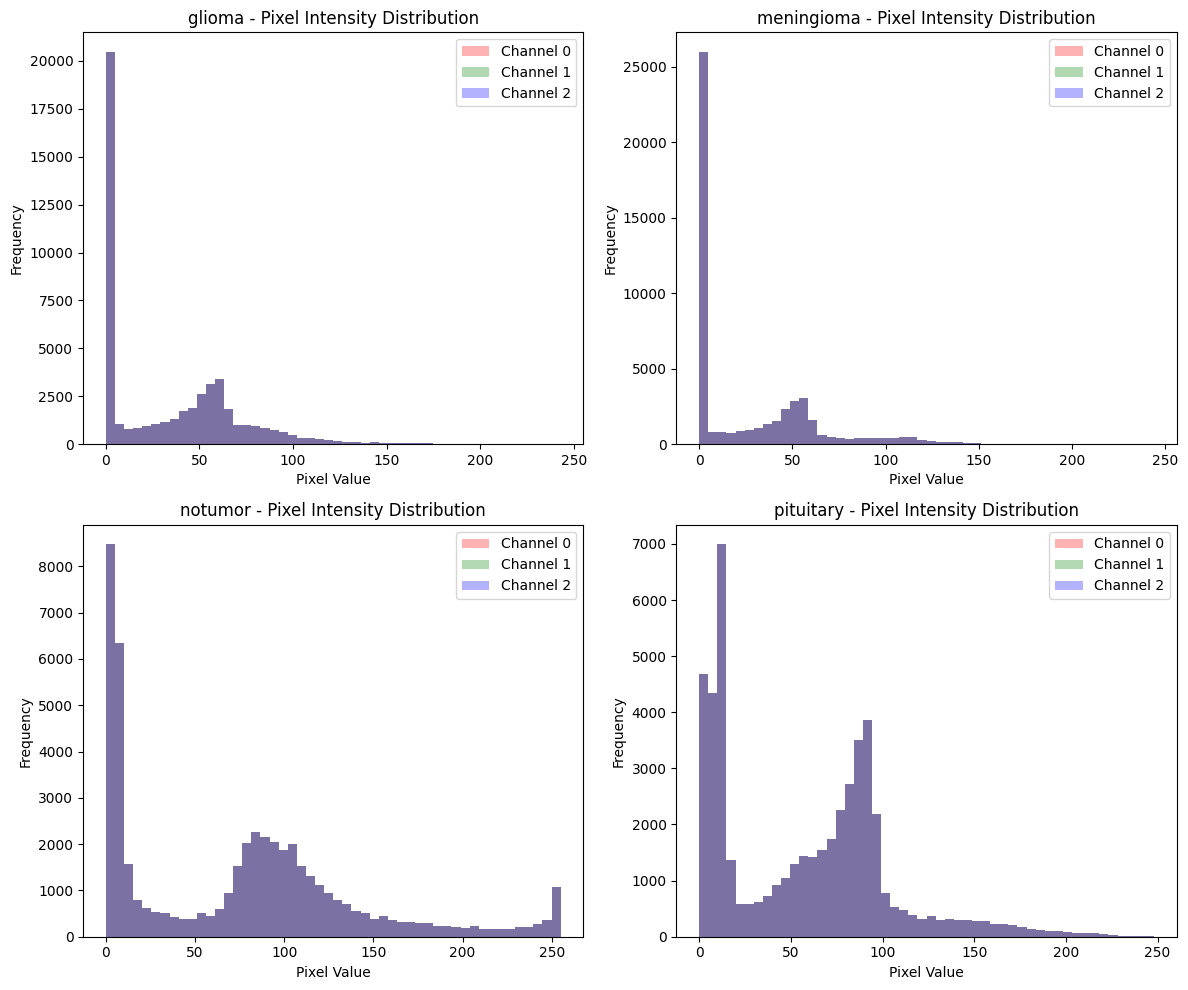

In [8]:
# Visualize pixel intensity distribution
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (class_name, img) in enumerate(zip(CLASSES, sample_images)):
    # RGB channels
    colors = ['red', 'green', 'blue']
    for channel, color in enumerate(colors):
        axes[idx].hist(img[:, :, channel].ravel(), bins=50, color=color, alpha=0.3, label=f'Channel {channel}')
    
    axes[idx].set_title(f'{class_name} - Pixel Intensity Distribution')
    axes[idx].set_xlabel('Pixel Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()

plt.tight_layout()
plt.show()

## 1.5 Create Train/Validation Split

In [9]:
from sklearn.model_selection import train_test_split

# Split training data into train and validation sets (80/20 split)
train_paths_split, val_paths, train_labels_split, val_labels = train_test_split(
    train_paths, train_labels, 
    test_size=0.2, 
    random_state=42, 
    stratify=train_labels  # Ensure balanced split
)

print(f"Training samples: {len(train_paths_split)}")
print(f"Validation samples: {len(val_paths)}")
print(f"Testing samples: {len(test_paths)}")

# Verify split is balanced
print("\nValidation set distribution:")
print(Counter(val_labels))

Training samples: 4480
Validation samples: 1120
Testing samples: 1600

Validation set distribution:
Counter({'glioma': 280, 'meningioma': 280, 'pituitary': 280, 'notumor': 280})


## 1.6 Label Encoding

In [10]:
from sklearn.preprocessing import LabelEncoder

# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(CLASSES)

# Transform labels
y_train = label_encoder.transform(train_labels_split)
y_val = label_encoder.transform(val_labels)
y_test = label_encoder.transform(test_labels)

print("Label Mapping:")
for idx, class_name in enumerate(label_encoder.classes_):
    print(f"  {idx}: {class_name}")

Label Mapping:
  0: glioma
  1: meningioma
  2: notumor
  3: pituitary


In [ ]:
# Save preprocessing metadata
metadata = {
    'img_size': IMG_SIZE,
    'classes': CLASSES,
    'class_indices': {class_name: idx for idx, class_name in enumerate(CLASSES)},
    'num_train_samples': len(train_paths_split),
    'num_val_samples': len(val_paths),
    'num_test_samples': len(test_paths),
    'num_classes': len(CLASSES)
}

import json
os.makedirs('processed_data', exist_ok=True)
with open('processed_data/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Preprocessing metadata saved!")
print(json.dumps(metadata, indent=2))